In [2]:
import numpy as np
import pandas as pd

In [3]:
dataset = pd.read_csv("employee_dataset_60_rows.csv")
dataset_work = dataset.copy()

In [4]:
def tax(income):
    if income > 50000:
        tax = (income * 20)/100
    else :
        tax = (income * 10)/100
    return tax

dataset_work['tax'] = dataset_work['Salary'].apply(tax)

In [5]:
gender_map = {"Male" : "M" , 
              "Female" : "F",
              "Unknown" : "U"}

dataset_work['Gender'] = dataset_work['Gender'].map(gender_map)

In [6]:
dataset_work = dataset_work.drop(columns="tax")
dataset_work = dataset_work.assign(tax = dataset_work['Salary'] * 20 /100)

In [7]:
dataset_work = dataset_work.rename(columns={"tax" : "Tax"})
salary_sorted_data = dataset_work.sort_values("Salary")
salary_sorted_data.reset_index(drop=True)
salary_sorted_data['Ranking'] = salary_sorted_data['Performance_Rating'].rank(ascending=False)

In [17]:
salary_sorted_data.sort_index()
practice_col = []
for col in salary_sorted_data.columns:
    if col == 'ID':
        continue
    else:
        practice_col.append(col)
practice_col.append('ID')
salary_copy = salary_sorted_data.copy()
salary_copy = salary_copy[practice_col]


In [29]:
#grouping and aggregation of data 
salary_copy.groupby("Department")["Salary"].mean()
salary_copy.groupby("Department")['Salary'].agg(avg_salary = "mean")

salary_copy.groupby("Department").agg(avg_salary = ("Salary" , "mean"))
salary_copy.groupby("Department").agg(
    avg_salary = ("Salary" , "mean"),
    avg_exp_years = ("Experience_Years" , "mean")
)

,avg_salary,avg_exp_years
Department,,
Finance,64162.500000,2.937500
HR,69100.000000,16.642857
IT,80000.000000,13.133333
Marketing,70833.333333,11.133333


<Axes: xlabel='Age', ylabel='Salary'>

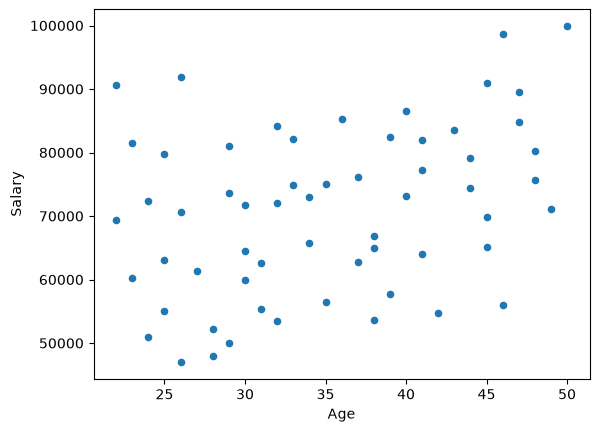

In [33]:
#salary_copy['Age'].plot()
salary_copy.plot(kind='scatter' , x="Age" , y="Salary")

In [8]:
salary_sorted_data

,ID,Name,Age,Gender,Department,Salary,City,Experience_Years,Education,Performance_Rating,Joining_Year,Employment_Type,Tax,Ranking
7,8,Hannah,26,F,Marketing,47000,Gurugram,15,PhD,4.8,1991,Part-Time,9400.0,6.0
2,3,Charlie,28,M,Finance,48000,Bengaluru,8,MBA,3.9,2004,Full-Time,9600.0,27.0
5,6,Frank,29,M,Finance,50000,Hyderabad,0,Master's,3.4,2020,Full-Time,10000.0,38.0
50,51,Adrian,24,M,Finance,51000,Delhi,0,MBA,3.7,2024,Full-Time,10200.0,31.5
34,35,Isaac,28,M,Finance,52200,Chennai,0,MBA,2.9,2020,Full-Time,10440.0,49.5
18,19,Sam,32,M,Finance,53400,Noida,4,MBA,4.7,2012,Full-Time,10680.0,8.5
52,53,Carter,38,M,HR,53600,Bengaluru,12,Bachelor's,2.5,1998,Full-Time,10720.0,59.0
36,37,Karan,42,M,HR,54800,Kolkata,16,Bachelor's,4.3,1990,Full-Time,10960.0,17.5
0,1,Alice,25,F,HR,55000,Delhi,0,Bachelor's,2.5,2026,Full-Time,11000.0,59.0
51,52,Bianca,31,F,Marketing,55300,Mumbai,8,PhD,4.4,2009,Part-Time,11060.0,15.5
